[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR-USERNAME/AI-in-healthcare-book/blob/main/notebooks/chapter_05/notebook_5_4_regression_metrics.ipynb)

*Click the badge above to open this notebook in Google Colab (no setup required)*

---


# 5.4 Regression Metrics for Healthcare Predictions

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Calculate and interpret regression metrics**: MAE, RMSE, R², MAPE
2. **Perform residual analysis** to diagnose model problems
3. **Understand clinical implications** of different error metrics
4. **Choose appropriate metrics** based on clinical context
5. **Compare models** using multiple regression metrics
6. **Identify and handle outliers** in clinical predictions

---

## Clinical Context: Why Regression Metrics Matter

**Journey Connection:**
- **David (CVD Risk)**: Predicting continuous 10-year CVD risk (0-100%)
- **Hospital LOS prediction**: Estimating length of stay (days)
- **Blood glucose forecasting**: Predicting future glucose levels
- **Medication dosing**: Predicting optimal drug concentration

**Key Questions:**
- Is MAE or RMSE more appropriate for predicting hospital length of stay?
- How do we interpret "R² = 0.65" for CVD risk prediction?
- What if our model systematically underestimates high-risk patients?
- Are large errors worse than many small errors (clinical cost function)?

**Why Different from Classification:**
- **Magnitude matters**: Being off by 5% vs 50% is very different
- **Direction matters**: Overestimation vs underestimation have different clinical costs
- **Scale matters**: Errors in glucose (mg/dL) vs CVD risk (%) use different units

---

## Setup

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error, median_absolute_error
)
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

# Set random seed
np.random.seed(42)

print("Setup complete!")

Setup complete!


---

## Part 1: Understanding Core Regression Metrics

### Key Metrics Overview

**1. Mean Absolute Error (MAE)**
- **Formula**: $\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$
- **Interpretation**: Average absolute difference between predicted and actual values
- **Units**: Same as target variable (e.g., days, %, mg/dL)
- **Clinical meaning**: "On average, predictions are off by X units"

**2. Root Mean Squared Error (RMSE)**
- **Formula**: $\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$
- **Interpretation**: Penalizes large errors more than MAE (due to squaring)
- **Units**: Same as target variable
- **Clinical meaning**: "Typical prediction error, with extra penalty for large misses"

**3. R² (Coefficient of Determination)**
- **Formula**: $R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$
- **Interpretation**: Proportion of variance explained by the model
- **Range**: -∞ to 1 (1 = perfect, 0 = baseline, <0 = worse than mean)
- **Clinical meaning**: "Model explains X% of the variability in outcomes"

**4. Mean Absolute Percentage Error (MAPE)**
- **Formula**: $\text{MAPE} = \frac{100\%}{n}\sum_{i=1}^{n}\frac{|y_i - \hat{y}_i|}{|y_i|}$
- **Interpretation**: Average percentage error (scale-independent)
- **Warning**: Undefined when $y_i = 0$, biased toward underestimates

### 1.1 Generate Synthetic Hospital Length of Stay Data

Dataset shape: (1000, 9)

Length of Stay Statistics:
count    1000.000000
mean        9.656193
std         4.927146
min         1.000000
25%         6.591638
50%         8.908216
75%        11.367458
max        30.000000
Name: los_days, dtype: float64


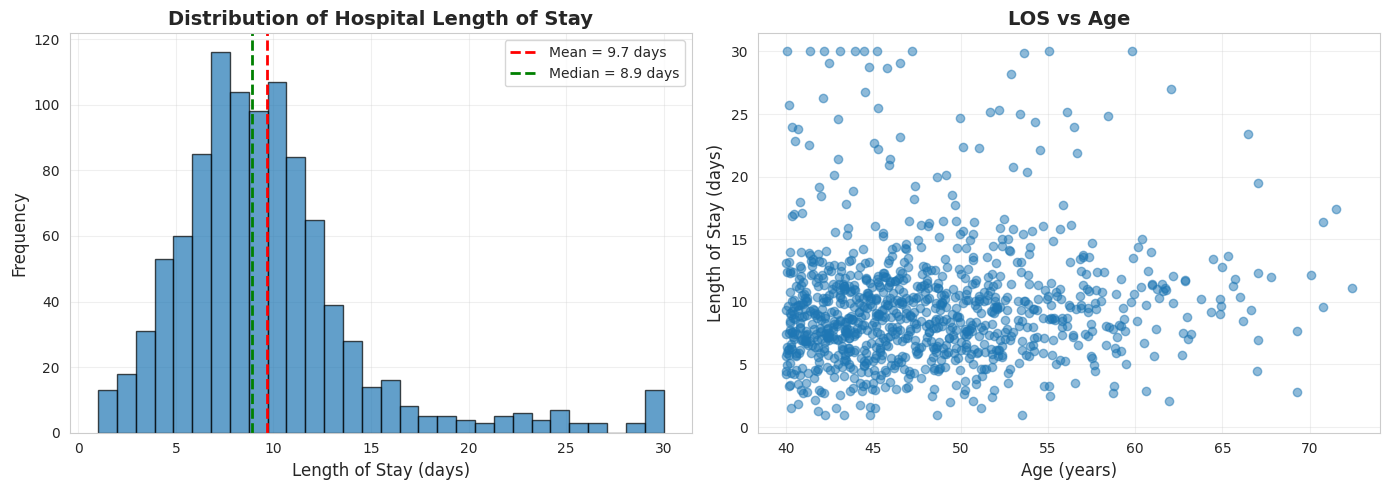

In [2]:
def generate_los_data(n_samples=1000):
    """
    Generate synthetic hospital length of stay (LOS) prediction data.

    Features:
    - Age, comorbidity score, admission severity
    - Labs (WBC, hemoglobin, creatinine)
    - Procedure complexity

    Target: Hospital LOS in days (1-30)
    """
    # Generate base features
    X, _ = make_regression(
        n_samples=n_samples,
        n_features=8,
        n_informative=6,
        noise=15,
        random_state=42
    )

    # Transform to realistic clinical ranges
    # Age
    X[:, 0] = 40 + np.abs(X[:, 0]) * 10  # Age: 40-80
    # Comorbidity score (Charlson)
    X[:, 1] = np.clip(np.abs(X[:, 1] * 2), 0, 10)
    # Admission severity (APACHE II-like)
    X[:, 2] = np.clip(np.abs(X[:, 2] * 5), 0, 35)
    # Labs
    X[:, 3] = 5 + np.abs(X[:, 3]) * 3  # WBC: 5-20
    X[:, 4] = 10 + X[:, 4] * 3  # Hemoglobin: 7-16
    X[:, 5] = 0.8 + np.abs(X[:, 5]) * 0.8  # Creatinine: 0.8-2.5
    # Procedure complexity
    X[:, 6] = np.clip(np.abs(X[:, 6]), 0, 5)
    # Emergency admission flag
    X[:, 7] = (X[:, 7] > 0).astype(float)

    # Generate LOS based on features
    los = (
        3 +  # Baseline
        0.05 * X[:, 0] +  # Age effect
        0.8 * X[:, 1] +   # Comorbidities
        0.15 * X[:, 2] +  # Severity
        0.3 * X[:, 3] +   # WBC
        -0.5 * X[:, 4] +  # Hemoglobin (lower = longer stay)
        1.5 * X[:, 5] +   # Creatinine
        1.2 * X[:, 6] +   # Procedure complexity
        2.0 * X[:, 7] +   # Emergency admission
        np.random.normal(0, 2, n_samples)  # Random variation
    )

    # Clip to realistic range and ensure positive
    los = np.clip(los, 1, 30)

    # Add some outliers (10% of patients have complicated courses)
    outlier_mask = np.random.random(n_samples) < 0.10
    los[outlier_mask] = los[outlier_mask] * np.random.uniform(1.5, 3, outlier_mask.sum())
    los = np.clip(los, 1, 30)

    feature_names = [
        'age', 'comorbidity_score', 'severity_score',
        'wbc', 'hemoglobin', 'creatinine',
        'procedure_complexity', 'emergency_admission'
    ]

    df = pd.DataFrame(X, columns=feature_names)
    df['los_days'] = los

    return df

# Generate data
df_los = generate_los_data(n_samples=1000)

print(f"Dataset shape: {df_los.shape}")
print(f"\nLength of Stay Statistics:")
print(df_los['los_days'].describe())

# Visualize distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(df_los['los_days'], bins=30, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Length of Stay (days)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of Hospital Length of Stay', fontsize=14, fontweight='bold')
ax1.axvline(df_los['los_days'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {df_los["los_days"].mean():.1f} days')
ax1.axvline(df_los['los_days'].median(), color='green', linestyle='--', linewidth=2, label=f'Median = {df_los["los_days"].median():.1f} days')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Correlation with age
ax2.scatter(df_los['age'], df_los['los_days'], alpha=0.5)
ax2.set_xlabel('Age (years)', fontsize=12)
ax2.set_ylabel('Length of Stay (days)', fontsize=12)
ax2.set_title('LOS vs Age', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.2 Train Models and Make Predictions

In [3]:
# Prepare data
feature_cols = ['age', 'comorbidity_score', 'severity_score', 'wbc',
                'hemoglobin', 'creatinine', 'procedure_complexity', 'emergency_admission']
X = df_los[feature_cols].values
y = df_los['los_days'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train linear regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_train = lr_model.predict(X_train_scaled)
y_pred_test = lr_model.predict(X_test_scaled)

print("Model trained successfully!")
print(f"\nPredictions (first 10 test patients):")
for i in range(10):
    print(f"  Patient {i+1}: Actual = {y_test[i]:.1f} days, Predicted = {y_pred_test[i]:.1f} days, Error = {y_test[i]-y_pred_test[i]:.1f}")

Model trained successfully!

Predictions (first 10 test patients):
  Patient 1: Actual = 7.6 days, Predicted = 7.3 days, Error = 0.3
  Patient 2: Actual = 7.1 days, Predicted = 5.8 days, Error = 1.3
  Patient 3: Actual = 5.6 days, Predicted = 10.8 days, Error = -5.1
  Patient 4: Actual = 4.5 days, Predicted = 6.8 days, Error = -2.2
  Patient 5: Actual = 5.0 days, Predicted = 8.2 days, Error = -3.2
  Patient 6: Actual = 10.7 days, Predicted = 9.7 days, Error = 1.0
  Patient 7: Actual = 6.8 days, Predicted = 9.9 days, Error = -3.1
  Patient 8: Actual = 2.9 days, Predicted = 2.8 days, Error = 0.1
  Patient 9: Actual = 6.4 days, Predicted = 6.0 days, Error = 0.4
  Patient 10: Actual = 6.3 days, Predicted = 8.9 days, Error = -2.6


### 1.3 Calculate All Core Metrics

In [4]:
def calculate_regression_metrics(y_true, y_pred):
    """
    Calculate comprehensive regression metrics.
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    # MAPE (handle zero values)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    # Median Absolute Error (robust to outliers)
    medae = median_absolute_error(y_true, y_pred)

    # Max error
    max_error = np.max(np.abs(y_true - y_pred))

    # Residuals
    residuals = y_true - y_pred

    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2,
        'MAPE': mape,
        'MedAE': medae,
        'Max Error': max_error,
        'Residuals': residuals
    }

# Calculate metrics for test set
metrics = calculate_regression_metrics(y_test, y_pred_test)

print("\n" + "="*60)
print("REGRESSION METRICS: Hospital Length of Stay Prediction")
print("="*60)
print(f"\nMean Absolute Error (MAE):          {metrics['MAE']:.3f} days")
print(f"  → On average, predictions are off by {metrics['MAE']:.2f} days")
print(f"\nRoot Mean Squared Error (RMSE):     {metrics['RMSE']:.3f} days")
print(f"  → Typical error is {metrics['RMSE']:.2f} days (penalizes large errors)")
print(f"\nMedian Absolute Error (MedAE):      {metrics['MedAE']:.3f} days")
print(f"  → Half of predictions are within {metrics['MedAE']:.2f} days (robust to outliers)")
print(f"\nMean Absolute Percentage Error:     {metrics['MAPE']:.2f}%")
print(f"  → Average error is {metrics['MAPE']:.1f}% of actual value")
print(f"\nR² Score:                           {metrics['R²']:.4f}")
print(f"  → Model explains {metrics['R²']*100:.1f}% of variance in LOS")
print(f"\nMaximum Error:                      {metrics['Max Error']:.3f} days")
print(f"  → Worst prediction was off by {metrics['Max Error']:.1f} days")
print("\n" + "="*60)

# Baseline comparison (always predict mean)
y_pred_baseline = np.full_like(y_test, y_train.mean())
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

print(f"\nBASELINE (Always predict mean = {y_train.mean():.1f} days):")
print(f"  MAE:  {mae_baseline:.3f} days")
print(f"  RMSE: {rmse_baseline:.3f} days")
print(f"\nImprovement over baseline:")
print(f"  MAE:  {(mae_baseline - metrics['MAE'])/mae_baseline * 100:.1f}% better")
print(f"  RMSE: {(rmse_baseline - metrics['RMSE'])/rmse_baseline * 100:.1f}% better")


REGRESSION METRICS: Hospital Length of Stay Prediction

Mean Absolute Error (MAE):          2.464 days
  → On average, predictions are off by 2.46 days

Root Mean Squared Error (RMSE):     3.792 days
  → Typical error is 3.79 days (penalizes large errors)

Median Absolute Error (MedAE):      1.633 days
  → Half of predictions are within 1.63 days (robust to outliers)

Mean Absolute Percentage Error:     33.42%
  → Average error is 33.4% of actual value

R² Score:                           0.3486
  → Model explains 34.9% of variance in LOS

Maximum Error:                      18.098 days
  → Worst prediction was off by 18.1 days


BASELINE (Always predict mean = 9.8 days):
  MAE:  3.433 days
  RMSE: 4.724 days

Improvement over baseline:
  MAE:  28.2% better
  RMSE: 19.7% better


### 1.4 Visual Comparison of Predictions

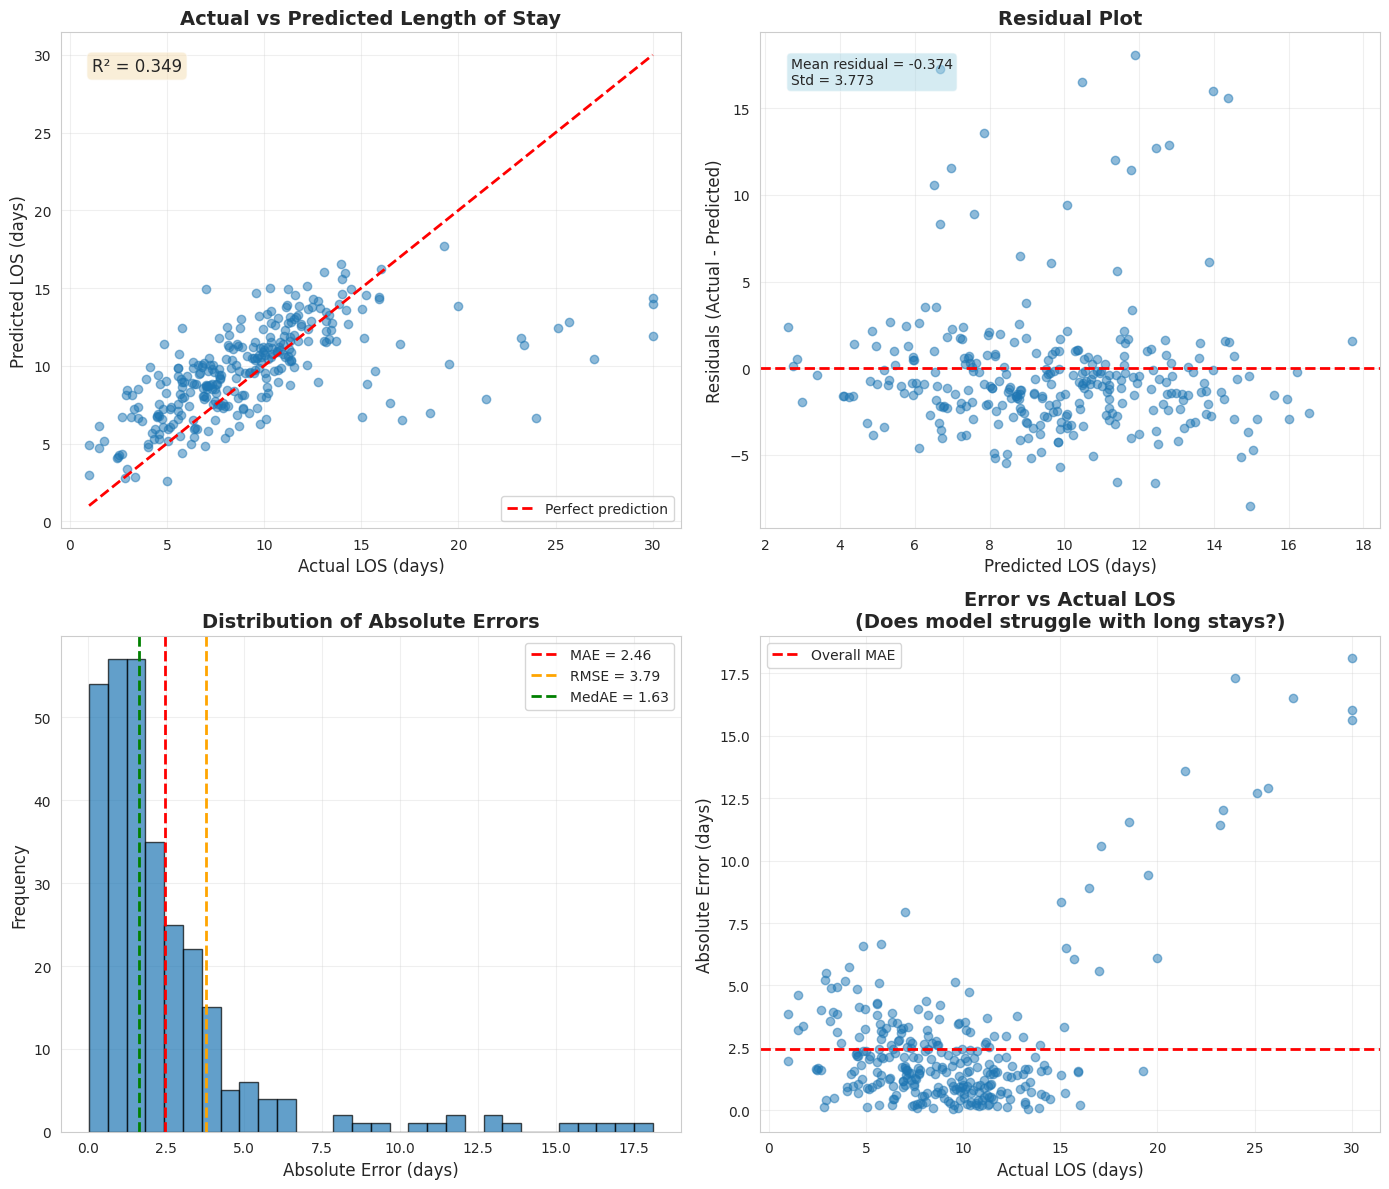


Key Observations from Plots:
1. Actual vs Predicted: Points near red line = good predictions
2. Residual Plot: Random scatter around 0 = good (no systematic bias)
3. Error Distribution: Most errors are small, but some large outliers exist
4. Error vs Actual: Check if errors increase for longer stays (heteroscedasticity)


In [5]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Actual vs Predicted
ax1 = axes[0, 0]
ax1.scatter(y_test, y_pred_test, alpha=0.5)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('Actual LOS (days)', fontsize=12)
ax1.set_ylabel('Predicted LOS (days)', fontsize=12)
ax1.set_title('Actual vs Predicted Length of Stay', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.text(0.05, 0.95, f'R² = {metrics["R²"]:.3f}',
         transform=ax1.transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Residual Plot
ax2 = axes[0, 1]
residuals = y_test - y_pred_test
ax2.scatter(y_pred_test, residuals, alpha=0.5)
ax2.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax2.set_xlabel('Predicted LOS (days)', fontsize=12)
ax2.set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
ax2.set_title('Residual Plot', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.text(0.05, 0.95, f'Mean residual = {residuals.mean():.3f}\nStd = {residuals.std():.3f}',
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# 3. Distribution of Errors
ax3 = axes[1, 0]
errors = np.abs(y_test - y_pred_test)
ax3.hist(errors, bins=30, edgecolor='black', alpha=0.7)
ax3.axvline(metrics['MAE'], color='red', linestyle='--', linewidth=2, label=f'MAE = {metrics["MAE"]:.2f}')
ax3.axvline(metrics['RMSE'], color='orange', linestyle='--', linewidth=2, label=f'RMSE = {metrics["RMSE"]:.2f}')
ax3.axvline(metrics['MedAE'], color='green', linestyle='--', linewidth=2, label=f'MedAE = {metrics["MedAE"]:.2f}')
ax3.set_xlabel('Absolute Error (days)', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title('Distribution of Absolute Errors', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Error by Actual LOS (does model struggle with long stays?)
ax4 = axes[1, 1]
ax4.scatter(y_test, errors, alpha=0.5)
ax4.axhline(metrics['MAE'], color='red', linestyle='--', linewidth=2, label=f'Overall MAE')
ax4.set_xlabel('Actual LOS (days)', fontsize=12)
ax4.set_ylabel('Absolute Error (days)', fontsize=12)
ax4.set_title('Error vs Actual LOS\n(Does model struggle with long stays?)', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Observations from Plots:")
print("1. Actual vs Predicted: Points near red line = good predictions")
print("2. Residual Plot: Random scatter around 0 = good (no systematic bias)")
print("3. Error Distribution: Most errors are small, but some large outliers exist")
print("4. Error vs Actual: Check if errors increase for longer stays (heteroscedasticity)")

---

## Part 2: Understanding MAE vs RMSE

### When Does RMSE > MAE?

**Key Insight**: RMSE is always ≥ MAE, with equality only when all errors are the same.

**Why the difference matters:**
- **MAE**: Treats all errors equally
- **RMSE**: Penalizes large errors more (due to squaring)

**Clinical interpretation:**
- If RMSE >> MAE → Many small errors and a few very large ones
- If RMSE ≈ MAE → Errors are consistent in magnitude

### 2.1 Demonstrate MAE vs RMSE with Different Error Patterns

In [6]:
# Create three scenarios
n = 100
y_true = np.full(n, 10)  # All actual values = 10

# Scenario 1: Consistent small errors
y_pred_consistent = y_true + np.random.normal(0, 1, n)  # σ = 1

# Scenario 2: Mix of small and large errors
y_pred_mixed = y_true.copy()
y_pred_mixed = y_pred_mixed.astype(float)
y_pred_mixed[:90] += np.random.normal(0, 0.5, 90)  # 90% small errors
y_pred_mixed[90:] += np.random.normal(0, 5, 10)    # 10% large errors

# Scenario 3: Few extreme outliers
y_pred_outliers = y_true + np.random.normal(0, 0.5, n)
y_pred_outliers[[5, 25, 75]] += np.array([15, -12, 18])  # 3 extreme outliers

scenarios = {
    'Consistent Small Errors': y_pred_consistent,
    'Mixed Small & Large': y_pred_mixed,
    'Few Extreme Outliers': y_pred_outliers
}

# Calculate metrics for each
results_comparison = []
for name, y_pred in scenarios.items():
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ratio = rmse / mae
    results_comparison.append({
        'Scenario': name,
        'MAE': mae,
        'RMSE': rmse,
        'RMSE/MAE': ratio
    })

df_comparison = pd.DataFrame(results_comparison)
print("\nMAE vs RMSE: Effect of Error Patterns")
print("=" * 70)
print(df_comparison.to_string(index=False))
print("\nInterpretation:")
print("  - RMSE/MAE ≈ 1.0: Errors are uniform")
print("  - RMSE/MAE > 1.3: Some large errors present")
print("  - RMSE/MAE > 1.5: Outliers have significant impact")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, y_pred) in zip(axes, scenarios.items()):
    errors = np.abs(y_true - y_pred)
    ax.hist(errors, bins=20, edgecolor='black', alpha=0.7)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.axvline(mae, color='blue', linestyle='--', linewidth=2, label=f'MAE={mae:.2f}')
    ax.axvline(rmse, color='red', linestyle='--', linewidth=2, label=f'RMSE={rmse:.2f}')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Absolute Error')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nClinical Implication:")
print("  If RMSE >> MAE for your LOS model:")
print("  → Some patients have very wrong predictions (investigate why!)")
print("  → Consider: Are these specific patient types? Rare conditions?")
print("  → Decision: Use MAE for typical performance, RMSE to check for outliers")

UFuncTypeError: Cannot cast ufunc 'add' output from dtype('float64') to dtype('int64') with casting rule 'same_kind'

---

## Part 3: Residual Analysis

### Why Residual Analysis Matters

**Residuals = Actual - Predicted**

**What we're looking for:**
1. **Mean ≈ 0**: No systematic bias
2. **Random scatter**: No patterns (heteroscedasticity, non-linearity)
3. **Normal distribution**: Validates many statistical assumptions
4. **No outliers**: Or investigate them

**Clinical importance:**
- Positive residuals = **Underestimation** (model predicts shorter LOS than actual)
- Negative residuals = **Overestimation** (model predicts longer LOS than actual)
- Systematic patterns = **Model is missing something important**

### 3.1 Comprehensive Residual Analysis

In [ ]:
residuals = y_test - y_pred_test

# Statistical tests
print("\nRESIDUAL ANALYSIS")
print("=" * 60)
print(f"Mean residual:              {residuals.mean():.4f} days")
print(f"  → Should be close to 0 (no systematic bias)")
print(f"\nStd of residuals:           {residuals.std():.4f} days")
print(f"\nMedian residual:            {np.median(residuals):.4f} days")
print(f"\n% Underestimated (res > 0): {(residuals > 0).mean()*100:.1f}%")
print(f"% Overestimated (res < 0):  {(residuals < 0).mean()*100:.1f}%")

# Test for normality
stat, p_value = stats.shapiro(residuals)
print(f"\nShapiro-Wilk test for normality:")
print(f"  p-value = {p_value:.4f}")
if p_value > 0.05:
    print(f"  → Residuals appear normally distributed (good!)")
else:
    print(f"  → Residuals deviate from normality (investigate!)")

# Identify outliers (> 3 standard deviations)
outlier_threshold = 3 * residuals.std()
outliers = np.abs(residuals) > outlier_threshold
print(f"\nOutliers (|residual| > {outlier_threshold:.2f}):")
print(f"  Count: {outliers.sum()} ({outliers.mean()*100:.1f}% of test set)")
if outliers.sum() > 0:
    print(f"  Max outlier: {np.abs(residuals[outliers]).max():.2f} days")

### 3.2 Visual Residual Diagnostics

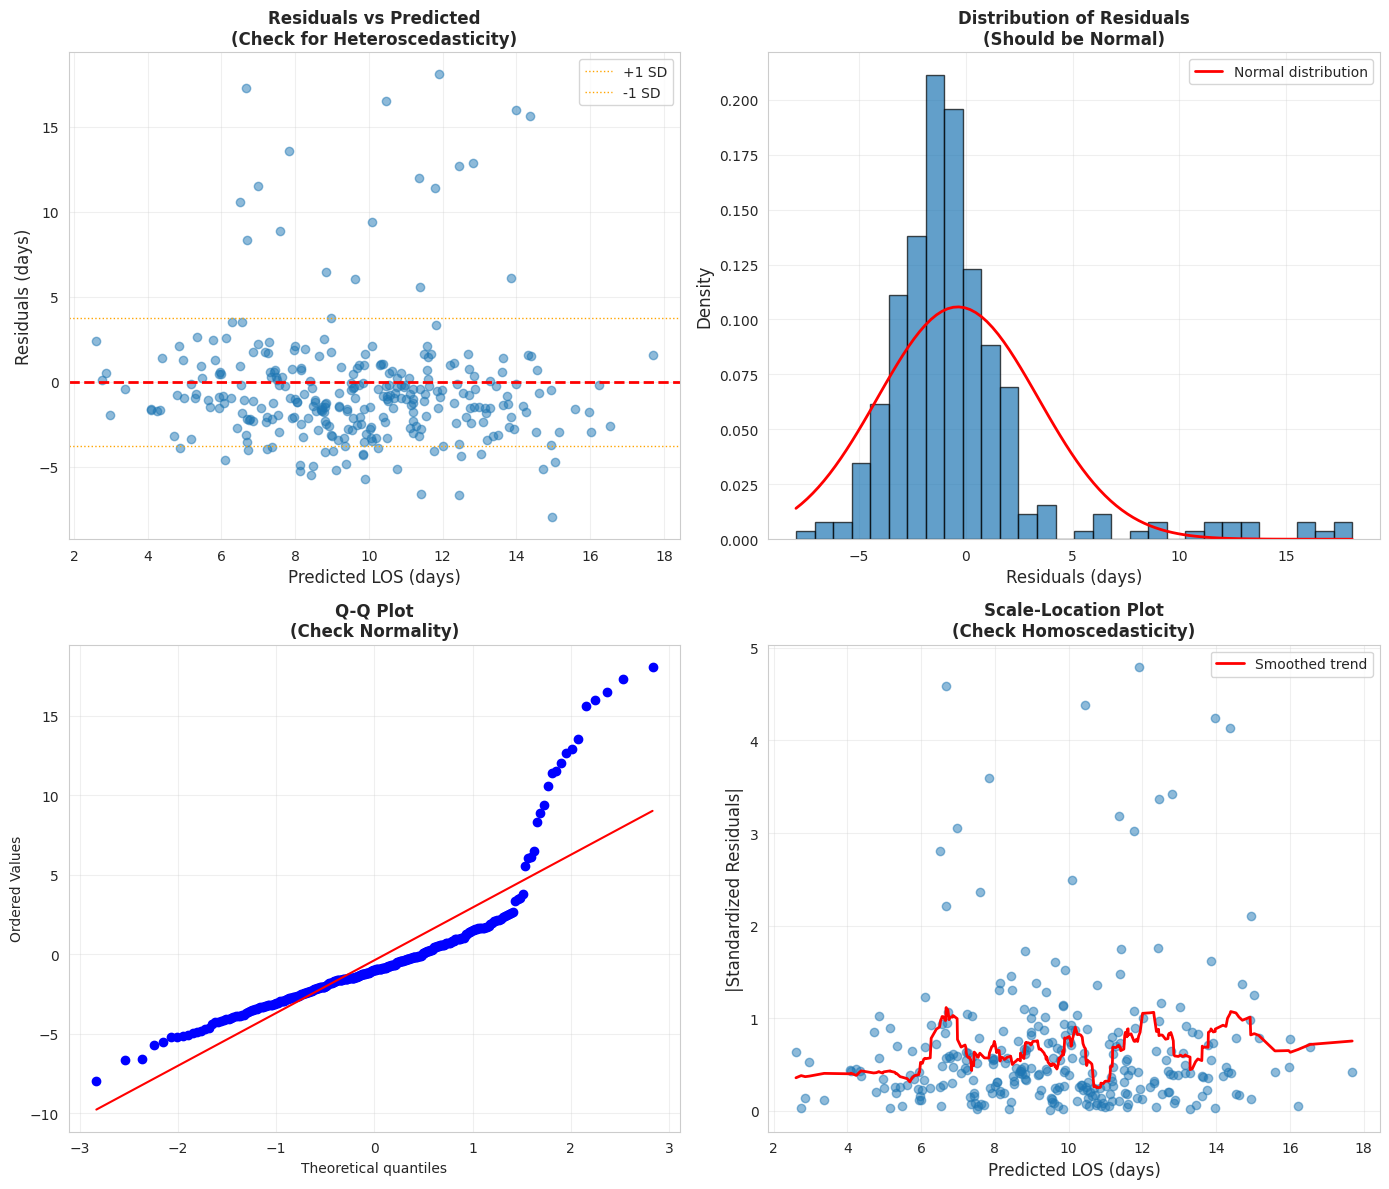


How to Interpret Residual Plots:

1. Residuals vs Predicted:
   - GOOD: Random scatter around 0 (no pattern)
   - BAD: Funnel shape (heteroscedasticity), curve (non-linearity)

2. Histogram of Residuals:
   - GOOD: Bell-shaped, symmetric around 0
   - BAD: Skewed, heavy tails, multiple peaks

3. Q-Q Plot:
   - GOOD: Points follow diagonal line
   - BAD: Deviation at ends (heavy tails), S-curve (skewness)

4. Scale-Location:
   - GOOD: Horizontal red line (homoscedasticity)
   - BAD: Increasing/decreasing trend (heteroscedasticity)


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Residuals vs Predicted (check for heteroscedasticity)
ax1 = axes[0, 0]
ax1.scatter(y_pred_test, residuals, alpha=0.5)
ax1.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax1.axhline(y=residuals.std(), color='orange', linestyle=':', linewidth=1, label='+1 SD')
ax1.axhline(y=-residuals.std(), color='orange', linestyle=':', linewidth=1, label='-1 SD')
ax1.set_xlabel('Predicted LOS (days)', fontsize=12)
ax1.set_ylabel('Residuals (days)', fontsize=12)
ax1.set_title('Residuals vs Predicted\n(Check for Heteroscedasticity)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Histogram of residuals (check for normality)
ax2 = axes[0, 1]
ax2.hist(residuals, bins=30, edgecolor='black', alpha=0.7, density=True)
# Overlay normal distribution
x = np.linspace(residuals.min(), residuals.max(), 100)
ax2.plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()),
         'r-', linewidth=2, label='Normal distribution')
ax2.set_xlabel('Residuals (days)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Distribution of Residuals\n(Should be Normal)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Q-Q plot (quantile-quantile plot for normality)
ax3 = axes[1, 0]
stats.probplot(residuals, dist="norm", plot=ax3)
ax3.set_title('Q-Q Plot\n(Check Normality)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. Scale-Location plot (standardized residuals vs predicted)
ax4 = axes[1, 1]
standardized_residuals = residuals / residuals.std()
ax4.scatter(y_pred_test, np.abs(standardized_residuals), alpha=0.5)
# Add smoothed trend line
from scipy.ndimage import uniform_filter1d
sorted_idx = np.argsort(y_pred_test)
smoothed = uniform_filter1d(np.abs(standardized_residuals[sorted_idx]), size=20)
ax4.plot(y_pred_test[sorted_idx], smoothed, 'r-', linewidth=2, label='Smoothed trend')
ax4.set_xlabel('Predicted LOS (days)', fontsize=12)
ax4.set_ylabel('|Standardized Residuals|', fontsize=12)
ax4.set_title('Scale-Location Plot\n(Check Homoscedasticity)', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nHow to Interpret Residual Plots:")
print("\n1. Residuals vs Predicted:")
print("   - GOOD: Random scatter around 0 (no pattern)")
print("   - BAD: Funnel shape (heteroscedasticity), curve (non-linearity)")
print("\n2. Histogram of Residuals:")
print("   - GOOD: Bell-shaped, symmetric around 0")
print("   - BAD: Skewed, heavy tails, multiple peaks")
print("\n3. Q-Q Plot:")
print("   - GOOD: Points follow diagonal line")
print("   - BAD: Deviation at ends (heavy tails), S-curve (skewness)")
print("\n4. Scale-Location:")
print("   - GOOD: Horizontal red line (homoscedasticity)")
print("   - BAD: Increasing/decreasing trend (heteroscedasticity)")

### 3.3 Investigate Large Residuals

In [ ]:
# Find worst predictions
abs_residuals = np.abs(residuals)
worst_idx = np.argsort(abs_residuals)[-10:]  # 10 worst

print("\n10 WORST PREDICTIONS (Largest Absolute Errors)")
print("=" * 80)
print(f"{'Actual':>8} {'Predicted':>10} {'Error':>8} {'% Error':>10}")
print("-" * 80)

for idx in worst_idx:
    actual = y_test[idx]
    pred = y_pred_test[idx]
    error = actual - pred
    pct_error = (error / actual) * 100
    print(f"{actual:8.1f} {pred:10.1f} {error:8.1f} {pct_error:10.1f}%")

print("\nPattern Analysis:")
print("  - Are most errors UNDERESTIMATES (error > 0) or OVERESTIMATES (error < 0)?")
print("  - Do errors occur for short stays or long stays?")
print("  - Clinical action: Investigate patient characteristics for outliers")

---

## Part 4: Understanding R² (Coefficient of Determination)

### What R² Really Means

**Formula**: $R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$

**Interpretation:**
- **R² = 1.0**: Perfect predictions (all variance explained)
- **R² = 0.0**: Model is no better than predicting the mean
- **R² < 0.0**: Model is WORSE than predicting the mean (terrible!)

**Common Misconception:**
- ❌ "R² = 0.65 means 65% of predictions are correct"
- ✅ "R² = 0.65 means model explains 65% of variance in outcomes"

**Clinical Context:**
- Healthcare often has R² = 0.3-0.7 (many unobserved factors)
- High R² doesn't mean clinically useful!
- Low R² doesn't mean useless (depends on baseline)

### 4.1 Visualize R² Interpretation

In [ ]:
# Calculate components of R²
y_mean = y_train.mean()
ss_tot = np.sum((y_test - y_mean)**2)  # Total sum of squares
ss_res = np.sum((y_test - y_pred_test)**2)  # Residual sum of squares
r2 = 1 - (ss_res / ss_tot)

print("\nUNDERSTANDING R² CALCULATION")
print("=" * 60)
print(f"Total Sum of Squares (SS_tot):     {ss_tot:.2f}")
print(f"  → Total variance in actual LOS")
print(f"\nResidual Sum of Squares (SS_res):  {ss_res:.2f}")
print(f"  → Variance NOT explained by model (errors)")
print(f"\nExplained Variance (SS_tot - SS_res): {ss_tot - ss_res:.2f}")
print(f"  → Variance explained by model")
print(f"\nR² = 1 - (SS_res / SS_tot) = 1 - ({ss_res:.2f} / {ss_tot:.2f})")
print(f"   = {r2:.4f}")
print(f"\nInterpretation:")
print(f"  Model explains {r2*100:.1f}% of variance in hospital length of stay")
print(f"  {(1-r2)*100:.1f}% of variance remains unexplained (due to unmeasured factors)")

# Visualize variance decomposition
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart of variance
ax1.pie([r2, 1-r2], labels=['Explained by Model', 'Unexplained (Residual)'],
        colors=['#4CAF50', '#FF9800'], autopct='%1.1f%%', startangle=90)
ax1.set_title(f'Variance Decomposition\nR² = {r2:.3f}', fontsize=14, fontweight='bold')

# Comparison to baseline
models_r2 = ['Baseline\n(Always predict mean)', 'Our Model']
r2_values = [0, r2]
colors_bar = ['red', 'green']
ax2.bar(models_r2, r2_values, color=colors_bar, alpha=0.7, edgecolor='black')
ax2.set_ylabel('R² Score', fontsize=12)
ax2.set_title('R² Comparison', fontsize=14, fontweight='bold')
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(r2_values):
    ax2.text(i, v + 0.05, f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 4.2 Adjusted R² (Penalizes Model Complexity)

In [ ]:
def adjusted_r2(r2, n, p):
    """
    Calculate adjusted R².

    Parameters:
    -----------
    r2 : float
        R² score
    n : int
        Number of samples
    p : int
        Number of features
    """
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

n_samples = len(y_test)
n_features = X_test.shape[1]
r2_score_val = r2_score(y_test, y_pred_test)
adj_r2 = adjusted_r2(r2_score_val, n_samples, n_features)

print("\nR² vs Adjusted R²")
print("=" * 60)
print(f"R²:           {r2_score_val:.4f}")
print(f"Adjusted R²:  {adj_r2:.4f}")
print(f"\nDifference:   {r2_score_val - adj_r2:.4f}")
print(f"\nAdjusted R² accounts for:")
print(f"  - Number of features: {n_features}")
print(f"  - Sample size: {n_samples}")
print(f"  - Penalizes overly complex models")
print(f"\nUse Adjusted R² when comparing models with different numbers of features!")

---

## Part 5: Comparing Multiple Models

### 5.1 Train Multiple Regression Models

In [ ]:
# Train multiple models
models_dict = {
    'Linear Regression': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0),
    'Lasso (L1)': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5)
}

results_models = []

for name, model in models_dict.items():
    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    results_models.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'MAPE%': mape
    })

df_results = pd.DataFrame(results_models)
df_results = df_results.sort_values('R²', ascending=False)

print("\nMODEL COMPARISON: Hospital Length of Stay Prediction")
print("=" * 80)
print(df_results.to_string(index=False))
print("\nBest model by:")
print(f"  Lowest MAE:  {df_results.loc[df_results['MAE'].idxmin(), 'Model']}")
print(f"  Lowest RMSE: {df_results.loc[df_results['RMSE'].idxmin(), 'Model']}")
print(f"  Highest R²:  {df_results.loc[df_results['R²'].idxmax(), 'Model']}")

### 5.2 Visualize Model Comparison

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# MAE comparison
ax1 = axes[0]
ax1.barh(df_results['Model'], df_results['MAE'], color='skyblue', edgecolor='black')
ax1.set_xlabel('MAE (days)', fontsize=12)
ax1.set_title('Mean Absolute Error\n(Lower is Better)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# RMSE comparison
ax2 = axes[1]
ax2.barh(df_results['Model'], df_results['RMSE'], color='lightcoral', edgecolor='black')
ax2.set_xlabel('RMSE (days)', fontsize=12)
ax2.set_title('Root Mean Squared Error\n(Lower is Better)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# R² comparison
ax3 = axes[2]
ax3.barh(df_results['Model'], df_results['R²'], color='lightgreen', edgecolor='black')
ax3.set_xlabel('R² Score', fontsize=12)
ax3.set_title('R² (Variance Explained)\n(Higher is Better)', fontsize=12, fontweight='bold')
ax3.set_xlim([0, 1])
ax3.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\nModel Selection Considerations:")
print("  - Tree-based models (RF, GBM) often have better MAE/RMSE")
print("  - Linear models are more interpretable")
print("  - Consider computational cost for deployment")
print("  - Validate on external dataset before final selection!")

---

## Key Takeaways

### 1. Core Metrics

**MAE (Mean Absolute Error)**
- Average absolute difference
- Same units as target
- Treats all errors equally
- Robust to outliers
- **Use when**: All errors have similar clinical cost

**RMSE (Root Mean Squared Error)**
- Penalizes large errors more
- Same units as target
- RMSE ≥ MAE always
- Sensitive to outliers
- **Use when**: Large errors are particularly bad clinically

**R² (Coefficient of Determination)**
- Proportion of variance explained (0-1)
- Scale-independent
- Can be negative (worse than baseline)
- **Use when**: Comparing models, understanding explanatory power

**MAPE (Mean Absolute Percentage Error)**
- Scale-independent (percentage)
- Easy to interpret
- Biased, undefined at zero
- **Use when**: Comparing across different scales

### 2. Choosing the Right Metric

| Clinical Scenario | Best Metric | Why |
|-------------------|-------------|-----|
| Hospital LOS | MAE | All prediction errors have similar impact |
| ICU mortality risk | RMSE | Missing high-risk patients is very costly |
| Comparing models across datasets | R², MAPE | Scale-independent comparison |
| Drug dosing | MAE, RMSE | Absolute error magnitude matters |
| Resource planning | MAE | Want typical error, not outlier-driven |

### 3. Residual Analysis

**Always check:**
- Mean ≈ 0 (no bias)
- Random scatter (no patterns)
- Normal distribution (validates assumptions)
- Investigate outliers

**Red flags:**
- Funnel shape → Heteroscedasticity
- Curved pattern → Non-linearity
- Skewed distribution → Transformation needed
- Many outliers → Missing important features

### 4. Clinical Interpretation

**Example: Hospital LOS Model**
- MAE = 2.1 days → "Typical error is ~2 days"
- RMSE = 2.8 days → "Some larger errors exist" (RMSE/MAE = 1.33)
- R² = 0.58 → "Explains 58% of variance" (42% due to unmeasured factors)
- MAPE = 25% → "On average, 25% off"

**Clinical question**: Is this good enough?
- Depends on use case!
- Discharge planning: MAE = 2.1 days might be acceptable
- Bed allocation: Need better accuracy
- Always compare to baseline (predicting mean)

### 5. Common Pitfalls

- ❌ Using only R² to evaluate models
- ❌ Not checking residual patterns
- ❌ Ignoring outliers without investigation
- ❌ Assuming high R² = clinically useful
- ❌ Not comparing to a sensible baseline

---

## Exercises

### Exercise 1: Metric Calculation
Given these predictions and actuals:
- Actual: [5, 10, 15, 20, 25]
- Predicted: [6, 9, 17, 19, 30]

Calculate by hand:
1. MAE
2. RMSE
3. R²
4. Why is RMSE > MAE?

### Exercise 2: Residual Analysis
1. Generate synthetic LOS data with systematic underestimation for long stays
2. Train a model and create residual plots
3. Identify the pattern in residuals
4. How would you fix this bias?

### Exercise 3: Metric Selection
For each scenario, choose MAE, RMSE, or both, and explain why:
1. Predicting blood glucose for insulin dosing
2. Forecasting hospital admissions for staffing
3. Estimating surgical duration
4. Predicting patient satisfaction scores (1-10)

### Exercise 4: Outlier Investigation
1. Find the 5 patients with largest prediction errors
2. Examine their features
3. Can you identify what makes them hard to predict?
4. Propose model improvements

### Exercise 5: Model Comparison
1. Train 3 different models on the LOS data
2. Compare MAE, RMSE, R²
3. Is the ranking consistent across metrics?
4. Which model would you deploy and why?

---

**Next Notebook**: 5.5 Segmentation Metrics for Medical Imaging